mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8525 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
Исходные данные:
  y  x1  x2
 60  14  70
 60  11 150
 87   8  60
 90  14  70
 75  10 130
100   6  59
 67   9 180
 80   8 115
 45  13  75
 50  15 138
100   7  70
 90   7  65
 65  10  91
 

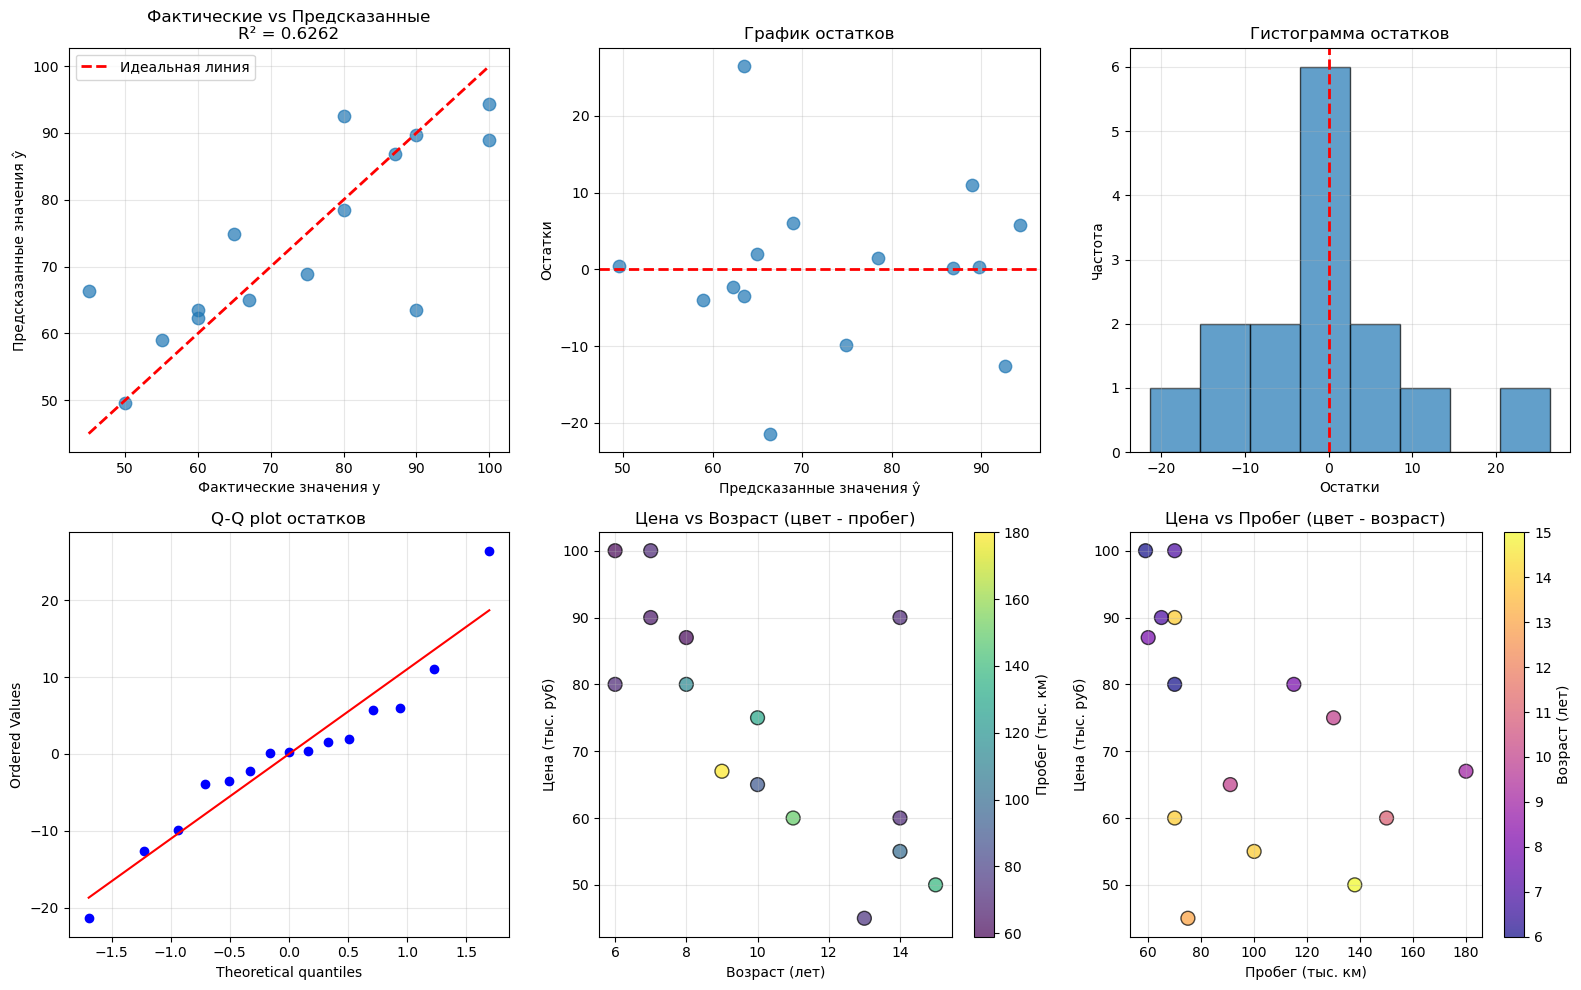

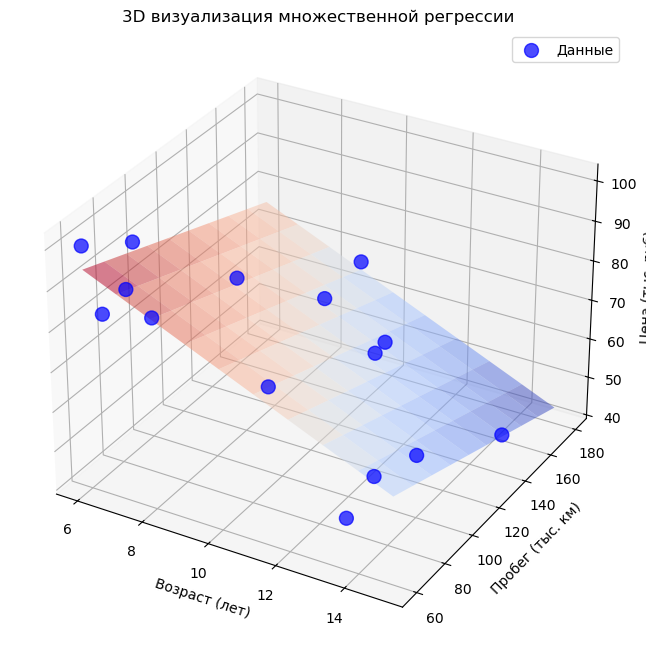


ПРИМЕР ПРЕДСКАЗАНИЯ

Для автомобиля:
  Возраст: 9 лет
  Пробег: 100 тыс. км
Прогнозируемая цена: 77.14 тыс. руб.
95% доверительный интервал: [51.20, 103.08] тыс. руб.

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ


         РЕЗУЛЬТАТЫ РЕГРЕССИОННОГО АНАЛИЗА        

 1. Уравнение регрессии:                           
    ŷ = 125.0492 + -3.6353·x₁ + -0.1519·x₂      

 2. Коэффициенты парной корреляции:                
    r_yx1 = -0.7255 (высокая)          
    r_yx2 = -0.4718 (умеренная)          
    r_x1x2 = 0.2263 (слабая)        

 3. Коэффициенты частной корреляции:               
    r_yx1|x2 = -0.7205 (высокая)          
    r_yx2|x1 = -0.4589 (умеренная)          

 4. Множественная корреляция и детерминация:       
    R = 0.7913                                     
    R² = 0.6262 (62.62% дисперсии объяснено)    
    R² скорр. = 0.6488                         

 5. Статистическая значимость:                     
    F-статистика = -27.6951                         
    F-критическое (α=0.05) 

In [1]:
!mamba install pandas

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Данные из таблицы варианта 17
data = {
    'y': [60, 60, 87, 90, 75, 100, 67, 80, 45, 50, 100, 90, 65, 55, 80],  # стоимость (тыс. руб)
    'x1': [14, 11, 8, 14, 10, 6, 9, 8, 13, 15, 7, 7, 10, 14, 6],          # возраст (лет)
    'x2': [70, 150, 60, 70, 130, 59, 180, 115, 75, 138, 70, 65, 91, 100, 70]  # пробег (тыс. км)
}

# Создаем DataFrame для удобства
df = pd.DataFrame(data)
print("Исходные данные:")
print(df.to_string(index=False))
print(f"\nКоличество наблюдений: {len(df)}")

# Преобразуем в numpy массивы
y = np.array(data['y'], dtype=float)
X1 = np.array(data['x1'], dtype=float)
X2 = np.array(data['x2'], dtype=float)

print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")

for name, arr in [('Цена (y)', y), ('Возраст (x1)', X1), ('Пробег (x2)', X2)]:
    print(f"\n{name}:")
    print(f"  Среднее: {np.mean(arr):.2f}")
    print(f"  Станд. отклонение: {np.std(arr, ddof=1):.2f}")
    print(f"  Минимум: {np.min(arr):.2f}")
    print(f"  Максимум: {np.max(arr):.2f}")
    print(f"  Медиана: {np.median(arr):.2f}")

print("ПАРНЫЕ КОЭФФИЦИЕНТЫ КОРРЕЛЯЦИИ")

# Матрица парных корреляций
corr_matrix = np.corrcoef([y, X1, X2])
print("\nМатрица парных корреляций (y, x1, x2):")
print("           y        x1       x2")
print(f"y   {corr_matrix[0,0]:10.4f} {corr_matrix[0,1]:10.4f} {corr_matrix[0,2]:10.4f}")
print(f"x1  {corr_matrix[1,0]:10.4f} {corr_matrix[1,1]:10.4f} {corr_matrix[1,2]:10.4f}")
print(f"x2  {corr_matrix[2,0]:10.4f} {corr_matrix[2,1]:10.4f} {corr_matrix[2,2]:10.4f}")

# Шкала Чеддока для интерпретации
def cherdock_scale(r):
    abs_r = abs(r)
    if abs_r < 0.1:
        return "очень слабая"
    elif abs_r < 0.3:
        return "слабая"
    elif abs_r < 0.5:
        return "умеренная"
    elif abs_r < 0.7:
        return "заметная"
    elif abs_r < 0.9:
        return "высокая"
    elif abs_r < 0.99:
        return "весьма высокая"
    else:
        return "функциональная"

# Интерпретируем корреляции
print("\nИнтерпретация связей (по шкале Чеддока):")
print(f"y и x1 (возраст): r = {corr_matrix[0,1]:.4f} - связь {cherdock_scale(corr_matrix[0,1])}")
print(f"y и x2 (пробег): r = {corr_matrix[0,2]:.4f} - связь {cherdock_scale(corr_matrix[0,2])}")
print(f"x1 и x2: r = {corr_matrix[1,2]:.4f} - связь {cherdock_scale(corr_matrix[1,2])}")

print("МНОЖЕСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ")

# Добавляем столбец единиц для свободного члена
X = np.column_stack([np.ones(len(X1)), X1, X2])

# Решаем нормальное уравнение: b = (X^T X)^(-1) X^T y
XTX = X.T @ X
XTY = X.T @ y
XTX_inv = np.linalg.inv(XTX)
b = XTX_inv @ XTY

b0, b1, b2 = b
print(f"\nУравнение регрессии:")
print(f"ŷ = {b0:.4f} + {b1:.4f}·x₁ + {b2:.4f}·x₂")
print(f"\nгде:")
print(f"  ŷ - predicted price (тыс. руб.)")
print(f"  x₁ - возраст автомобиля (лет)")
print(f"  x₂ - пробег (тыс. км)")

# Интерпретация коэффициентов
print(f"\nИнтерпретация коэффициентов:")
print(f"b₀ = {b0:.4f} - теоретическая стоимость нового автомобиля с нулевым пробегом (тыс. руб.)")
print(f"b₁ = {b1:.4f} - при увеличении возраста на 1 год стоимость изменяется на {b1:.4f} тыс. руб.")
print(f"b₂ = {b2:.4f} - при увеличении пробега на 1 тыс. км стоимость изменяется на {b2:.4f} тыс. руб.")


# Остатки
y_pred = X @ b
residuals = y - y_pred

# Оценка дисперсии остатков
n = len(y)
p = 3  # число параметров (b0, b1, b2)
mse = np.sum(residuals**2) / (n - p)

# Стандартные ошибки коэффициентов
se_b = np.sqrt(mse * np.diag(XTX_inv))

# t-статистики
t_stats = b / se_b

# p-значения
p_values = [2 * (1 - stats.t.cdf(abs(t), n-p)) for t in t_stats]

print("\n" + "-"*40)
print("ПРОВЕРКА ЗНАЧИМОСТИ КОЭФФИЦИЕНТОВ")
print("-"*40)
print(f"{'Коэф.':<8} {'Значение':<12} {'Ст.ошибка':<12} {'t-стат.':<10} {'p-знач.':<10}")
print("-"*52)
print(f"b₀    {b0:<12.4f} {se_b[0]:<12.4f} {t_stats[0]:<10.4f} {p_values[0]:<10.4f}")
print(f"b₁    {b1:<12.4f} {se_b[1]:<12.4f} {t_stats[1]:<10.4f} {p_values[1]:<10.4f}")
print(f"b₂    {b2:<12.4f} {se_b[2]:<12.4f} {t_stats[2]:<10.4f} {p_values[2]:<10.4f}")

alpha = 0.05
print(f"\nПри уровне значимости α = {alpha}:")
for i, (name, p) in enumerate(zip(['b₀', 'b₁', 'b₂'], p_values)):
    if p < alpha:
        print(f"  {name} статистически значим (p = {p:.4f} < {alpha})")
    else:
        print(f"  {name} статистически не значим (p = {p:.4f} > {alpha})")

print("ЧАСТНЫЕ КОЭФФИЦИЕНТЫ КОРРЕЛЯЦИИ")

# Функция для расчета частной корреляции
def partial_corr(r12, r13, r23):

    return (r12 - r13 * r23) / np.sqrt((1 - r13**2) * (1 - r23**2))

# Извлекаем парные корреляции
r_yx1 = corr_matrix[0, 1]  # корреляция y и x1
r_yx2 = corr_matrix[0, 2]  # корреляция y и x2
r_x1x2 = corr_matrix[1, 2]  # корреляция x1 и x2

# Частная корреляция между y и x1 при фиксированном x2
r_yx1_x2 = partial_corr(r_yx1, r_yx2, r_x1x2)

# Частная корреляция между y и x2 при фиксированном x1
r_yx2_x1 = partial_corr(r_yx2, r_yx1, r_x1x2)

print(f"\nПарные корреляции:")
print(f"  r_yx1 = {r_yx1:.4f}")
print(f"  r_yx2 = {r_yx2:.4f}")
print(f"  r_x1x2 = {r_x1x2:.4f}")

print(f"\nЧастные корреляции:")
print(f"  r_yx1|x2 = {r_yx1_x2:.4f} - корреляция цены с возрастом при фиксированном пробеге")
print(f"  r_yx2|x1 = {r_yx2_x1:.4f} - корреляция цены с пробегом при фиксированном возрасте")

print(f"\nСравнение парных и частных корреляций:")
print(f"  y-x1: парная = {r_yx1:.4f}, частная = {r_yx1_x2:.4f}, разница = {abs(r_yx1 - r_yx1_x2):.4f}")
print(f"  y-x2: парная = {r_yx2:.4f}, частная = {r_yx2_x1:.4f}, разница = {abs(r_yx2 - r_yx2_x1):.4f}")

print(f"\nИнтерпретация частных корреляций (по шкале Чеддока):")
print(f"  Связь цены с возрастом (при постоянном пробеге): {cherdock_scale(r_yx1_x2)}")
print(f"  Связь цены с пробегом (при постоянном возрасте): {cherdock_scale(r_yx2_x1)}")

print("МНОЖЕСТВЕННЫЙ КОЭФФИЦИЕНТ КОРРЕЛЯЦИИ И ДЕТЕРМИНАЦИИ")

# Множественный коэффициент корреляции
# Вариант 1: через корреляцию фактических и предсказанных значений
R = np.corrcoef(y, y_pred)[0, 1]

# Вариант 2: через парные корреляции (для проверки)
R_alt = np.sqrt((r_yx1**2 + r_yx2**2 - 2*r_yx1*r_yx2*r_x1x2) / (1 - r_x1x2**2))

print(f"Множественный коэффициент корреляции R:")
print(f"  R = {R:.4f} (через корреляцию y и ŷ)")
print(f"  R = {R_alt:.4f} (через парные корреляции)")

# Коэффициент множественной детерминации
R2 = R**2
print(f"\nКоэффициент множественной детерминации R²:")
print(f"  R² = {R2:.4f}")

# Скорректированный R² (с учетом числа факторов)
R2_adj = 1 - (1 - R2) * (n - 1) / (n - p)
print(f"  R² скорр. = {R2_adj:.4f} (с поправкой на число факторов)")

print(f"\nИнтерпретация:")
print(f"  Модель объясняет {R2*100:.2f}% вариации цены автомобиля")
print(f"  {100 - R2*100:.2f}% вариации объясняется неучтенными факторами")

# F-тест для проверки значимости модели в целом
F_stat = (R2 / (p-1)) / ((1 - R2) / (n - p))
F_crit = stats.f.ppf(0.95, p-1, n-p)  # критическое значение при α=0.05

print(f"\nF-тест для проверки значимости модели в целом:")
print(f"  F-статистика = {F_stat:.4f}")
print(f"  F-критическое (α=0.05) = {F_crit:.4f}")
if F_stat > F_crit:
    print(f"  F > F_крит → модель статистически значима")
else:
    print(f"  F < F_крит → модель статистически не значима")

print("АНАЛИЗ ОСТАТКОВ")

print(f"\nСумма остатков: {np.sum(residuals):.2e} (должна быть близка к 0)")

# Проверка на нормальность остатков (простой тест)
from scipy.stats import shapiro
stat, p_value = shapiro(residuals)
print(f"\nТест Шапиро-Уилка на нормальность остатков:")
print(f"  Статистика: {stat:.4f}")
print(f"  p-значение: {p_value:.4f}")
if p_value > 0.05:
    print(f"  Остатки распределены нормально (p > 0.05)")
else:
    print(f"  Остатки НЕ распределены нормально (p < 0.05)")


print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")

# Создаем фигуру с несколькими графиками
fig = plt.figure(figsize=(16, 10))

#  Фактические vs предсказанные значения
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(y, y_pred, alpha=0.7, s=80)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальная линия')
ax1.set_xlabel('Фактические значения y')
ax1.set_ylabel('Предсказанные значения ŷ')
ax1.set_title(f'Фактические vs Предсказанные\nR² = {R2:.4f}')
ax1.grid(True, alpha=0.3)
ax1.legend()

#  Остатки vs предсказанные значения
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(y_pred, residuals, alpha=0.7, s=80)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Предсказанные значения ŷ')
ax2.set_ylabel('Остатки')
ax2.set_title('График остатков')
ax2.grid(True, alpha=0.3)

#  Гистограмма остатков
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(residuals, bins=8, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Остатки')
ax3.set_ylabel('Частота')
ax3.set_title('Гистограмма остатков')
ax3.grid(True, alpha=0.3)

#  Q-Q plot для проверки нормальности остатков
ax4 = fig.add_subplot(2, 3, 4)
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.set_title('Q-Q plot остатков')
ax4.grid(True, alpha=0.3)

#  Зависимость цены от возраста (цветом показан пробег)
ax5 = fig.add_subplot(2, 3, 5)
sc = ax5.scatter(X1, y, c=X2, cmap='viridis', s=100, alpha=0.7, edgecolors='black')
plt.colorbar(sc, ax=ax5, label='Пробег (тыс. км)')
ax5.set_xlabel('Возраст (лет)')
ax5.set_ylabel('Цена (тыс. руб)')
ax5.set_title('Цена vs Возраст (цвет - пробег)')
ax5.grid(True, alpha=0.3)

#  Зависимость цены от пробега (цветом показан возраст)
ax6 = fig.add_subplot(2, 3, 6)
sc = ax6.scatter(X2, y, c=X1, cmap='plasma', s=100, alpha=0.7, edgecolors='black')
plt.colorbar(sc, ax=ax6, label='Возраст (лет)')
ax6.set_xlabel('Пробег (тыс. км)')
ax6.set_ylabel('Цена (тыс. руб)')
ax6.set_title('Цена vs Пробег (цвет - возраст)')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3D визуализация
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Точки данных
ax.scatter(X1, X2, y, c='blue', s=100, alpha=0.7, label='Данные')

# Плоскость регрессии
x1_grid, x2_grid = np.meshgrid(
    np.linspace(X1.min(), X1.max(), 10),
    np.linspace(X2.min(), X2.max(), 10)
)
y_grid = b0 + b1 * x1_grid + b2 * x2_grid
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, cmap='coolwarm')

ax.set_xlabel('Возраст (лет)')
ax.set_ylabel('Пробег (тыс. км)')
ax.set_zlabel('Цена (тыс. руб)')
ax.set_title('3D визуализация множественной регрессии')
ax.legend()

plt.savefig('regression_3d.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n" + "="*60)
print("ПРИМЕР ПРЕДСКАЗАНИЯ")
print("="*60)

# Пример для конкретного автомобиля
new_car_age = 9  # лет
new_car_mileage = 100  # тыс. км

pred_price = b0 + b1 * new_car_age + b2 * new_car_mileage
print(f"\nДля автомобиля:")
print(f"  Возраст: {new_car_age} лет")
print(f"  Пробег: {new_car_mileage} тыс. км")
print(f"Прогнозируемая цена: {pred_price:.2f} тыс. руб.")

# Доверительный интервал
# Создаем вектор для нового наблюдения
X_new = np.array([1, new_car_age, new_car_mileage])
# Дисперсия предсказания
var_pred = mse * (1 + X_new @ XTX_inv @ X_new)
se_pred = np.sqrt(var_pred)
# Доверительный интервал (95%)
t_crit = stats.t.ppf(0.975, n-p)
ci_lower = pred_price - t_crit * se_pred
ci_upper = pred_price + t_crit * se_pred

print(f"95% доверительный интервал: [{ci_lower:.2f}, {ci_upper:.2f}] тыс. руб.")

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

print(f"""

         РЕЗУЛЬТАТЫ РЕГРЕССИОННОГО АНАЛИЗА        

 1. Уравнение регрессии:                           
    ŷ = {b0:.4f} + {b1:.4f}·x₁ + {b2:.4f}·x₂      
                                                   
 2. Коэффициенты парной корреляции:                
    r_yx1 = {r_yx1:.4f} ({cherdock_scale(r_yx1)})          
    r_yx2 = {r_yx2:.4f} ({cherdock_scale(r_yx2)})          
    r_x1x2 = {r_x1x2:.4f} ({cherdock_scale(r_x1x2)})        
                                                   
 3. Коэффициенты частной корреляции:               
    r_yx1|x2 = {r_yx1_x2:.4f} ({cherdock_scale(r_yx1_x2)})          
    r_yx2|x1 = {r_yx2_x1:.4f} ({cherdock_scale(r_yx2_x1)})          
                                                
 4. Множественная корреляция и детерминация:       
    R = {R:.4f}                                     
    R² = {R2:.4f} ({R2*100:.2f}% дисперсии объяснено)    
    R² скорр. = {R2_adj:.4f}                         
                                                   
 5. Статистическая значимость:                     
    F-статистика = {F_stat:.4f}                         
    F-критическое (α=0.05) = {F_crit:.4f}               
    Модель {'статистически значима' if F_stat > F_crit else 'статистически не значима'}      
""")

print("\nРабота завершена. Графики сохранены в файлах:")
print("  - regression_analysis.png")
print("  - regression_3d.png")